In [1]:
import copy, json, yaml, numpy as np, torch, torch.nn as nn, pandas as pd, cantera as ct
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

MECH       = 'burke_chem_opt.yaml'
CARLY_CHEB = 'carly_opt_cheb.yaml'
TOY_MECH   = 'chem_cti_toy_model_ogog.yaml'   # the mechanism the surrogates were trained on

# order of the checkpoint parameter vector x
PARAM_ORDER = ['R1', 'R2', 'R5', 'R4']

# (label, 0-based Cantera reaction index in MECH, is_falloff)
RXN_SPECS = [('R2', 25, False), ('R5', 4, False), ('R4', 18, False)]

CARLY_EQUATIONS = {
    'R2': 'H2O2 + OH <=> H2O + HO2',
    'R5': '2 OH <=> H2O + O',
    'R4': 'HO2 + OH <=> H2O + O2',
}
CARLY_DIRECTION = {'R2': 'forward', 'R5': 'forward', 'R4': 'forward'}

# Burke's own MSI-optimized target conditions (T, P), not the nominal Hong
# shock-tube readings -- same convention as Carly's CONDITIONS in
# carly_model_time_history.ipynb, which likewise uses her optimized T/P rather
# than nominal. Mole fractions are left at nominal: Burke's optimized values
# differ from nominal by <0.5%, well under plotting resolution.
CONDITIONS = {
    '1192K': dict(T=1195.547, P_atm=1.953, xH2O2=2220e-6, xH2O=1360e-6, xO2=680e-6,
                  oh_csv='hong_1192K_oh.csv', h2o_csv='hong_1192K_h2o.csv'),
    '1398K': dict(T=1398.639, P_atm=1.909, xH2O2=2540e-6, xH2O=1230e-6, xO2=620e-6,
                  oh_csv='hong_1398K_oh.csv', h2o_csv='hong_1398K_h2o.csv'),
}

CHECKPOINTS = {
    ('1192K'): 'result_1192k_train_final4.pt',
    ('1398K'): 'result_1398k_train_final4.pt',
}
    
LN_F, SIGMA_E = np.log(10.0), 5000.0
SIG_LOG, LOG_EPS, NOISE_FLOOR = 0.05, 1e-12, 1e-12
SIG_PRIOR_X = 0.5
TAU_PRIOR_US, TAU_BOUND_US = 2.0, 6.0

In [2]:
ANALYSIS_RESULT = 'analysis_1192_1398_f4_20260914_212926/result.json'   # latest joint analysis run

with open(ANALYSIS_RESULT) as f:
    _res = json.load(f)

assert _res['param_names'][::2] == ['lnA_' + r for r in PARAM_ORDER], (
    f"PARAM_ORDER {PARAM_ORDER} does not match {ANALYSIS_RESULT}: {_res['param_names']}")

FITS = {
    'integrated': dict(param_names=_res['param_names'],
                       x_opt=np.asarray(_res['x_opt'], float),   # NN-surrogate optimum (pre Cantera-verification)
                       Sigma=np.asarray(_res['Sigma'], float),
                       tau_opt=_res['tau_us'], fit_on=_res['fit'], source=ANALYSIS_RESULT),
}
print(f"  integrated <- {ANALYSIS_RESULT}  (fit on {_res['fit']})")
print(f"           x_opt = {np.round(FITS['integrated']['x_opt'], 4)}")


  integrated <- analysis_1192_1398_f4_20260914_212926/result.json  (fit on ['1192', '1398'])
           x_opt = [-0.3987 -0.4686 -0.0814 -0.1133 -0.1427 -0.1085 -0.1355  0.0987]


In [3]:
_toy_gas = ct.Solution(TOY_MECH)
RXN_EQUATION = {name: _toy_gas.reaction(idx).equation for name, idx, fall in RXN_SPECS}
RXN_TOY_BASE = {}
for name, idx, fall in RXN_SPECS:
    r = _toy_gas.reaction(idx)
    base = r.rate.low_rate if fall else r.rate
    RXN_TOY_BASE[name] = dict(A=base.pre_exponential_factor, Ea=base.activation_energy)
del _toy_gas
print('Reaction equations (from', TOY_MECH, '):')
for name, eq in RXN_EQUATION.items():
    print(f'  {name}: {eq}')


def resolve_reaction(gas, name, fall):
    '''Return (idx_to_perturb, [other duplicate indices, left untouched]) for
    reaction `name` in `gas`. See mark down above for why this matters.'''
    eq = RXN_EQUATION[name]
    candidates = [i for i in range(gas.n_reactions) if gas.reaction(i).equation == eq]
    if len(candidates) == 1:
        return candidates[0], []
    ref = RXN_TOY_BASE[name]
    def rate_of(i):
        r = gas.reaction(i)
        return r.rate.low_rate if fall else r.rate
    def err(i):
        rt = rate_of(i)
        return (abs(rt.pre_exponential_factor - ref['A'])/ref['A'] +
                abs(rt.activation_energy - ref['Ea'])/max(abs(ref['Ea']), 1.0))
    best = min(candidates, key=err)
    return best, [i for i in candidates if i != best]


def perturb_gas(x, mech=TOY_MECH):
    '''Apply x to EVERY duplicate branch of each reaction, on the TOY mechanism.

    x* was determined relative to the toy's rate constants, so the optimized
    k(T) is k_toy(T) * multiplier. burke_chem_opt.yaml and carly_opt_cheb.yaml
    are OPTIMIZED MSI models, not nominals -- they are comparison targets, never
    a base to perturb.

    Previously only resolve_reaction's best-matching branch was scaled while
    k_vs_T_by_name summed all of them, so the plotted multiplier was
    f*m + (1-f) instead of m, where f is the perturbed branch's share of k(T).
    Scaling all branches by the same A factor and shifting all by the same Ea
    makes the common factor come out of the sum exactly:
        k'(T) = k(T) * exp(x_A*LN_F - x_Ea*SIGMA_E/RT)
    '''
    gas = ct.Solution(mech)
    for name, idx_hint, fall in RXN_SPECS:
        p = 2 * PARAM_ORDER.index(name)   # this reaction's slot in the checkpoint vector x
        idx, dupes = resolve_reaction(gas, name, fall)
        for j in [idx] + dupes:
            r = gas.reaction(j)
            base = r.rate.low_rate if fall else r.rate
            A_new  = base.pre_exponential_factor * np.exp(x[p] * LN_F)
            Ea_new = base.activation_energy + x[p+1]*SIGMA_E*4184.0   # cal/mol -> J/kmol
            if fall:
                r.rate.low_rate = ct.Arrhenius(A_new, base.temperature_exponent, Ea_new)
            else:
                r.rate = ct.Arrhenius(A_new, base.temperature_exponent, Ea_new)
            gas.modify_reaction(j, r)
    return gas


def check_multiplier(x, mech=TOY_MECH, T_check=(1192.0, 1398.0)):
    '''k'(T)/k(T) must equal exp(x_A*LN_F - x_Ea*SIGMA_E/RT) for every reaction.
    Fails loudly if a duplicate branch was missed.'''
    R = ct.gas_constant / 4184.0                    # cal/(mol K)
    g0, g1 = ct.Solution(mech), perturb_gas(x, mech)
    worst = 0.0
    for name, idx_hint, fall in RXN_SPECS:
        p = 2 * PARAM_ORDER.index(name)
        for T in T_check:
            k0 = k_vs_T_by_name(g0, name, fall, np.array([T]), P_ref, X_ref)[0]
            k1 = k_vs_T_by_name(g1, name, fall, np.array([T]), P_ref, X_ref)[0]
            want = np.exp(x[p]*LN_F - x[p+1]*SIGMA_E/(R*T))
            rel = abs(k1/k0/want - 1.0); worst = max(worst, rel)
            print(f"    {name} @{T:.0f} K  k'/k = {k1/k0:.6f}  want {want:.6f}  "
                  f"rel {rel:.2e}  {'ok' if rel < 1e-8 else 'MISMATCH'}")
    return worst


def build_carly_gas(carly_file=CARLY_CHEB):
    return ct.Solution(carly_file)


def k_vs_T(gas, idx, direction, T_grid, P, X):
    k = np.empty(len(T_grid))
    for i, T in enumerate(T_grid):
        gas.TPX = T, P, X
        k[i] = gas.reverse_rate_constants[idx] if direction == 'reverse' else gas.forward_rate_constants[idx]
    return k


def k_vs_T_by_name(gas, name, fall, T_grid, P, X):
    idx, dupes = resolve_reaction(gas, name, fall)
    all_idx = [idx] + dupes
    k = np.empty(len(T_grid))
    for i, T in enumerate(T_grid):
        gas.TPX = T, P, X
        rates = gas.forward_rate_constants
        k[i] = sum(rates[j] for j in all_idx)
    return k


UNIT_FACTOR = {'R2': 1e3, 'R5': 1e3, 'R4': 1e3}
UNIT_LABEL  = {'R2': 'k(T)   [cm^3 / (mol s)]',
               'R5': 'k(T)   [cm^3 / (mol s)]',
               'R4': 'k(T)   [cm^3 / (mol s)]'}


def to_reported_units(name, k):
    k = k * UNIT_FACTOR[name]
    k[~np.isfinite(k) | (k <= 0)] = np.nan
    return k

Reaction equations (from chem_cti_toy_model_ogog.yaml ):
  R2: H2O2 + OH <=> H2O + HO2
  R5: 2 OH <=> H2O + O
  R4: HO2 + OH <=> H2O + O2


In [4]:
T_grid = np.linspace(200, 2500.0, 400)
P_ref  = 1.00 * ct.one_atm
X_ref  = {'H2O2': 2200e-6, 'H2O': 1300e-6, 'O2': 650e-6,
          'AR': 1.0 - (2200e-6 + 1300e-6 + 650e-6)}   # representative Hong-like bath composition

burke_gas   = ct.Solution(MECH)   # Burke MSI-optimized model (a comparison target)
toy_gas     = ct.Solution(TOY_MECH)   # the mechanism the surrogates were TRAINED on
carly_gas   = build_carly_gas()
# reaction index of each target in carly_opt_cheb.yaml (declaration order == Cantera index)
_carly_eqs = [r['equation'] for r in yaml.safe_load(open(CARLY_CHEB))['reactions']]
CARLY_IDX  = {name: _carly_eqs.index(CARLY_EQUATIONS[name]) for name, _, _ in RXN_SPECS}

k_burke = {name: to_reported_units(name, k_vs_T_by_name(burke_gas, name, fall, T_grid, P_ref, X_ref))
           for name, idx, fall in RXN_SPECS}

k_toy = {name: to_reported_units(name, k_vs_T_by_name(toy_gas, name, fall, T_grid, P_ref, X_ref))
         for name, idx, fall in RXN_SPECS}
for name, idx, fall in RXN_SPECS:
    i1192 = int(np.argmin(abs(T_grid - 1192.0)))
    print(f'  {name}: k_toy/k_nominal @1192 K = {k_toy[name][i1192]/k_burke[name][i1192]:.3f}')

k_carly = {name: to_reported_units(name, k_vs_T(carly_gas, CARLY_IDX[name], CARLY_DIRECTION[name], T_grid, P_ref, X_ref))
           for name, idx, fall in RXN_SPECS}

k_opt = {}
for key, fit in FITS.items():
    print(f"multiplier check for {key} (x* from {fit['source']}):")
    if check_multiplier(fit['x_opt']) > 1e-8:
        raise SystemExit('perturbation is not a clean multiplicative factor -- '
                         'a duplicate branch is being missed')
    g = perturb_gas(fit['x_opt'])
    k_opt[key] = {name: to_reported_units(name, k_vs_T_by_name(g, name, fall, T_grid, P_ref, X_ref))
                  for name, idx, fall in RXN_SPECS}

print('Done.')

  R2: k_toy/k_nominal @1192 K = 1.054
  R5: k_toy/k_nominal @1192 K = 1.251
  R4: k_toy/k_nominal @1192 K = 2.103
multiplier check for integrated (x* from analysis_1192_1398_f4_20260914_212926/result.json):
    R2 @1192 K  k'/k = 1.053155  want 1.053155  rel 4.44e-16  ok
    R2 @1398 K  k'/k = 1.016693  want 1.016693  rel 6.66e-16  ok
    R5 @1192 K  k'/k = 0.905198  want 0.905198  rel 1.33e-15  ok
    R5 @1398 K  k'/k = 0.875164  want 0.875164  rel 0.00e+00  ok
    R4 @1192 K  k'/k = 0.594384  want 0.594384  rel 0.00e+00  ok
    R4 @1398 K  k'/k = 0.612905  want 0.612905  rel 0.00e+00  ok
Done.


/tmp/ipykernel_544685/2886612872.py:60: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  r.rate = ct.Arrhenius(A_new, base.temperature_exponent, Ea_new)


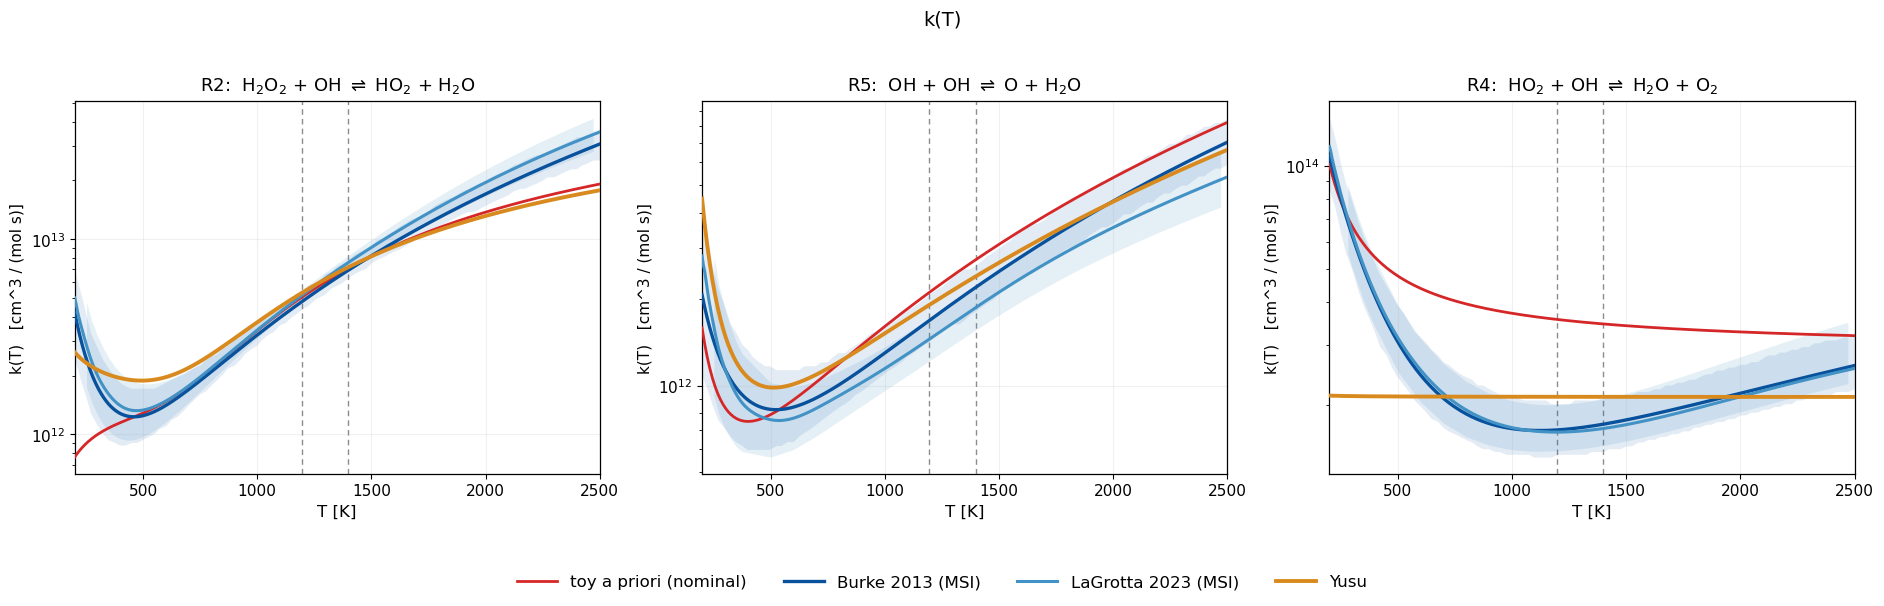

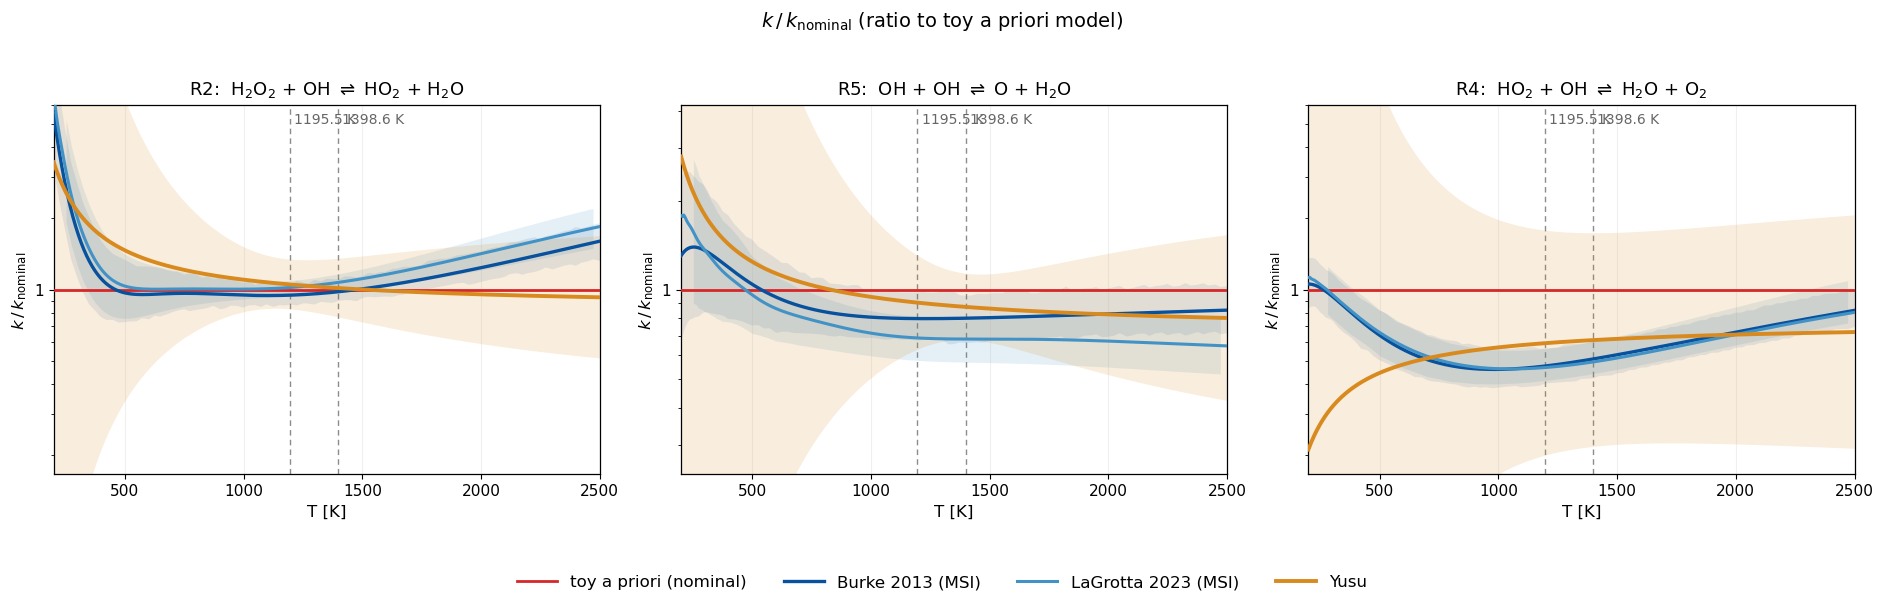

In [5]:
import matplotlib.ticker as mticker

REACTION_LABEL = {
    'R2': r'R2:  H$_2$O$_2$ + OH $\rightleftharpoons$ HO$_2$ + H$_2$O',
    'R5': r'R5:  OH + OH $\rightleftharpoons$ O + H$_2$O',
    'R4': r'R4:  HO$_2$ + OH $\rightleftharpoons$ H$_2$O + O$_2$',
}

# ── literature uncertainty envelopes ─────────────────────────────────────────
_burke_bands = pd.read_csv('figS4_blue_errorbars.csv', comment='#', skiprows=1)
BURKE_BAND = {rid: g.sort_values('T_K') for rid, g in _burke_bands.groupby('reaction_id')}
_carly_bands = pd.read_csv('figS42_blue_envelopes_gridded.csv', comment='#', skiprows=1)
_CARLY_PANEL = {'R2': 'tl_H2O2_OH', 'R5': 'bl_OH_OH', 'R4': 'tr_HO2_OH'}
CARLY_BAND = {name: _carly_bands[_carly_bands['panel'] == p].sort_values('T_K')
              for name, p in _CARLY_PANEL.items()}

# ── palette ──────────────────────────────────────────────────────────────────
# Burke lab convention: nominal = red, MSI = blue. This study's result is also an
# MSI result, so it stays on the cool side -- but purple/magenta rather than blue,
# or it would be indistinguishable from the two published models. The two
# reference blues are separated by LIGHTNESS, not hue, so they survive greyscale
# printing and colour-vision deficiency.
C_TOY   = '#D62728'    # a priori / nominal  -- red, per lab convention
C_BURKE = '#08519C'    # Burke 2013 MSI      -- dark blue
C_CARLY = '#4292C6'    # LaGrotta 2023 MSI   -- mid blue
FIT_STYLE = {                       # keys must match FITS
    'integrated': dict(color="#D98A1EFF", T_fit=None, label='Yusu'),  # amber
}
# Burke's own MSI-optimized target temperatures (see CONDITIONS), not the
# nominal 1192/1398 K Hong readings.
T_DATA = (CONDITIONS['1192K']['T'], CONDITIONS['1398K']['T'])
T_RANGE = (200.0, 2500.0)

def posterior_lnk_sd(name, fit):
    """2sigma band on THIS study's k(T), propagated from Sigma*.
    ln k = ln A_nom + x_A*LN_F - (Ea_nom + x_Ea*SIGMA_E)/(R T), so
      Var[ln k] = LN_F^2 S_AA - 2 LN_F (SIGMA_E/RT) S_AE + (SIGMA_E/RT)^2 S_EE
    Narrowest at the pivot T* -- the temperature the data actually constrains --
    and fanning out away from it. This is independent of whatever reference
    curve k is divided by (Burke, toy nominal, ...) since that reference has
    no propagated uncertainty of its own."""
    R = ct.gas_constant / 4184.0
    p = 2 * PARAM_ORDER.index(name)
    S = fit['Sigma'][p:p+2, p:p+2]
    g = SIGMA_E / (R * T_grid)
    var = LN_F**2 * S[0,0] - 2*LN_F*g*S[0,1] + g**2 * S[1,1]
    return np.sqrt(np.clip(var, 0, None))

on_grid = lambda df, cn: np.interp(T_grid, df['T_K'].values, df[cn].values, left=np.nan, right=np.nan)

plt.rcParams.update({'font.size': 12, 'axes.linewidth': 0.9})

# ══════════════════════════════ Figure 1: absolute k(T) ═════════════════════
fig1, axes1 = plt.subplots(1, 3, figsize=(19, 5.5))
for col, (name, idx, fall) in enumerate(RXN_SPECS):
    ax = axes1[col]
    b, c = BURKE_BAND.get(name), CARLY_BAND.get(name)
    if b is not None and len(b):
        ax.fill_between(T_grid, on_grid(b,'k_lower'), on_grid(b,'k_upper'),
                        color=C_BURKE, alpha=0.11, lw=0, zorder=1)
    if c is not None and len(c):
        ax.fill_between(T_grid, on_grid(c,'k_lower'), on_grid(c,'k_upper'),
                        color=C_CARLY, alpha=0.14, lw=0, zorder=1)
    ax.plot(T_grid, k_toy[name],   color=C_TOY,   lw=2.0, zorder=3, label='toy a priori (nominal)')
    ax.plot(T_grid, k_burke[name], color=C_BURKE, lw=2.4, zorder=4, label='Burke 2013 (MSI)')
    ax.plot(T_grid, k_carly[name], color=C_CARLY, lw=2.2, zorder=4, label='LaGrotta 2023 (MSI)')
    for key, st in FIT_STYLE.items():
        if key not in k_opt: continue
        ax.plot(T_grid, k_opt[key][name], color=st['color'], lw=2.8, zorder=5, label=st['label'])
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=8))
    ax.set_ylabel(UNIT_LABEL[name], fontsize=11)
    ax.set_xlabel('T [K]', fontsize=12)
    ax.set_title(REACTION_LABEL[name], fontsize=13, pad=8)
    ax.set_xlim(*T_RANGE)
    for T0 in T_DATA:
        ax.axvline(T0, color='0.55', ls=(0,(4,3)), lw=1.0, zorder=0)
    ax.grid(True, which='major', ls='-', alpha=0.18)
    ax.tick_params(labelsize=11)

h, l = axes1[0].get_legend_handles_labels()
fig1.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02),
           ncol=len(l), fontsize=12, frameon=False, handlelength=2.4, columnspacing=2.2)
fig1.suptitle('k(T)', fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# ══════════════════════════ Figure 2: k(T) / k_nominal(T) ════════════════════
# ratio to the TOY a priori model -- shows what the fit (and the published MSI
# models) changed relative to where the toy mechanism started, not relative to
# each other.
fig2, axes2 = plt.subplots(1, 3, figsize=(19, 5.5))
for col, (name, idx, fall) in enumerate(RXN_SPECS):
    ax = axes2[col]
    ref = k_toy[name]
    b, c = BURKE_BAND.get(name), CARLY_BAND.get(name)
    if b is not None and len(b):
        ax.fill_between(T_grid, on_grid(b,'k_lower')/ref, on_grid(b,'k_upper')/ref,
                        color=C_BURKE, alpha=0.11, lw=0, zorder=1)
    if c is not None and len(c):
        ax.fill_between(T_grid, on_grid(c,'k_lower')/ref, on_grid(c,'k_upper')/ref,
                        color=C_CARLY, alpha=0.14, lw=0, zorder=1)
    ax.axhline(1.0, color=C_TOY, lw=2.0, zorder=3, label='toy a priori (nominal)')
    ax.plot(T_grid, k_burke[name]/ref, color=C_BURKE, lw=2.4, zorder=4, label='Burke 2013 (MSI)')
    ax.plot(T_grid, k_carly[name]/ref, color=C_CARLY, lw=2.2, zorder=4, label='LaGrotta 2023 (MSI)')
    spans = []
    for key, st in FIT_STYLE.items():
        if key not in k_opt: continue
        r  = k_opt[key][name]/ref
        sd = posterior_lnk_sd(name, FITS[key])
        ax.fill_between(T_grid, r*np.exp(-2*sd), r*np.exp(+2*sd),
                        color=st['color'], alpha=0.15, lw=0, zorder=2)
        ax.plot(T_grid, r, color=st['color'], lw=2.8, zorder=6, label=st['label'])
        if st['T_fit'] is not None:
            ax.plot([st['T_fit']], [np.interp(st['T_fit'], T_grid, r)], 'o',
                    color=st['color'], ms=8, mec='white', mew=1.4, zorder=7)
        spans.append(r)
    spans.append(k_burke[name]/ref); spans.append(k_carly[name]/ref)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:g}'))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    d = np.nanmax([np.nanpercentile(np.abs(np.log(np.clip(s, 1e-6, None))), 99) for s in spans])
    m = float(np.clip(np.exp(max(d * 1.6, np.log(1.35))), 1.35, 6.0))
    ax.set_ylim(1/m, m)
    ax.set_ylabel(r'$k\,/\,k_{\mathrm{nominal}}$', fontsize=12)
    ax.set_xlabel('T [K]', fontsize=12)
    ax.set_title(REACTION_LABEL[name], fontsize=13, pad=8)
    ax.set_xlim(*T_RANGE)
    for T0 in T_DATA:
        ax.axvline(T0, color='0.55', ls=(0,(4,3)), lw=1.0, zorder=0)
    ax.grid(True, which='major', ls='-', alpha=0.18)
    ax.tick_params(labelsize=11)
    for T0 in T_DATA:
        ax.annotate(f'{T0:.1f} K', xy=(T0, 1), xycoords=('data','axes fraction'),
                    xytext=(3,-5), textcoords='offset points',
                    fontsize=10, color='0.4', va='top')

h, l = axes2[0].get_legend_handles_labels()
fig2.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02),
           ncol=len(l), fontsize=12, frameon=False, handlelength=2.4, columnspacing=2.2)
fig2.suptitle(r'$k\,/\,k_{\mathrm{nominal}}$ (ratio to toy a priori model)', fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0.06, 1, 1])
# fig1.savefig('fig_k_vs_T.png', dpi=150, bbox_inches='tight')
# fig2.savefig('fig_k_vs_T_ratio_nominal.png', dpi=150, bbox_inches='tight')
plt.show()